# 3.2 Ejercicios: efecto de mundo pequeño

Ana Luisa Llamas Martinez

ENES-Juriquilla

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import binom, poisson
import numpy as np
import math
import pandas as pd

def grafo_erdos_renyi(N, p, seed=None):
    """
    Genera una realización del grafo aleatorio G(N,p).
    """
    if seed is not None:
        random.seed(seed)

    G = nx.Graph()
    G.add_nodes_from(range(N))

    for i in range(N):
        for j in range(i + 1, N):
            if random.random() < p:
                G.add_edge(i, j)

    return G

def dibujar_realizaciones(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def dibujar_realizaciones_con_esperanza(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]
    L_esperado = p * N * (N-1) / 2
    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}\nE[L]={L_esperado:.2f}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def simular_numero_aristas(N, p, n_sim=1000):
    valores_L = []
    for s in range(n_sim):
        G = grafo_erdos_renyi(N,p, seed=s)
        valores_L.append(G.number_of_edges())

    return valores_L

## Ejercicio 1. Red regular y distancias.

Considere una red regular en anillo con N=100 nodos, donde cada nodo está conectado con sus k=4 vecinos más cercanos.

- Genere la red.
- Dibuje la red obtenida.
- Calcule el coeficiente de clustering promedio.
- Calcule la longitud media de camino entre nodos.
- Interprete los resultados.

In [2]:
N1 = 100
k1 = 4
p1 = 0
G1 = nx.watts_strogatz_graph(N1, k1, p1)

coef_clust_prom1 = nx.average_clustering(G1)
long_med_cam1 = nx.average_shortest_path_length(G1)

print(f"El coeficiente de clustering promedio es {coef_clust_prom1}, mientras que la longitud media de caminos entre nodos es {long_med_cam1}")

El coeficiente de clustering promedio es 0.5, mientras que la longitud media de caminos entre nodos es 12.878787878787879


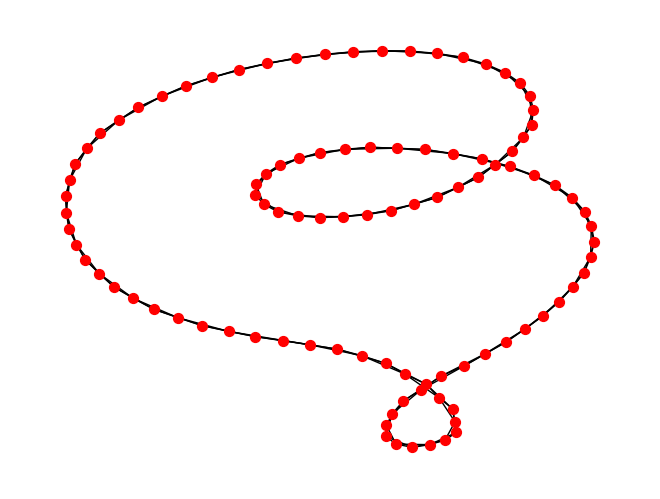

In [3]:
nx.draw(G1, node_size=50, node_color='red')

**Pregunta conceptual.**

¿Cómo describiría la estructura local y global de esta red?

**R=** A nivel local, los nodos están considerablemente conectados (al menos con sus vecinos). En cambio, a nivel global, dos nodos que no sean vecinos sí están demasiado separados.

## Ejercicio 2. Efecto de reconectar algunas aristas.

Considere redes de Watts–Strogatz con N=100, k=4 y distintos valores de la probabilidad de reconexión

$$\beta = 0, 0.01, 0.05, 0.1, 0.5, 1.$$

Para cada valor de $\beta$:
- Genere una realización de la red.
- Calcule el coeficiente de clustering promedio.
- Calcule la longitud media de camino.
- Organice los resultados en una tabla.

In [4]:
N2 = 100
k2 = 4
beta2 = [0, 0.01, 0.05, 0.1, 0.5, 1]

cluster2 = []
longitud2 = []

for i in beta2:
    g = nx.watts_strogatz_graph(N2, k2, i)

    coef = nx.average_clustering(g)
    long = nx.average_shortest_path_length(g)

    cluster2.append(coef)
    longitud2.append(long)


In [5]:
data2 = {'Beta (p)': beta2, 'Clustering Promedio': cluster2, 'Longitud Media': longitud2}

df2 = pd.DataFrame(data2)

print(df2)

   Beta (p)  Clustering Promedio  Longitud Media
0      0.00             0.500000       12.878788
1      0.01             0.479333        9.713737
2      0.05             0.440000        6.437172
3      0.10             0.352667        4.845455
4      0.50             0.066905        3.586061
5      1.00             0.024095        3.459798


**Pregunta conceptual.**

¿Cómo cambian el clustering y la longitud media de camino al aumentar $\beta$?

**R=** En ambos casos disminuye. No obstante, el rango de beta donde hay una disminución drástica es diferente.



## Ejercicio 3. Régimen de mundo pequeño.

Considere el modelo de Watts–Strogatz con N=100 y k=4.

- Para varios valores de $\beta$, calcule:
    $$ C(\beta), L(\beta)$$
- Normalice estos valores respecto al caso regular $\beta = 0$:
    $$\frac{C(\beta)}{C(0)}, \frac{L(\beta)}{L(0)}.$$
- Grafique ambas cantidades en función de $\beta$.
- Identifique el rango de valores de $\beta$ en el que la red presenta efecto de mundo pequeño.

In [6]:
N3 = 100
k3 = 4

beta3 = np.linspace(0.01, 0.5, 50)

clustering3 = []
aristas3 = []

g0 = nx.watts_strogatz_graph(N3, k3, 0)
c0 = nx.average_clustering(g0)
l0 = nx.average_shortest_path_length(g0)

for i in beta3:
    g = nx.watts_strogatz_graph(N3, k3, i)

    c = nx.average_clustering(g) / c0
    clustering3.append(c)

    l = nx.average_shortest_path_length(g) / l0 
    aristas3.append(l)

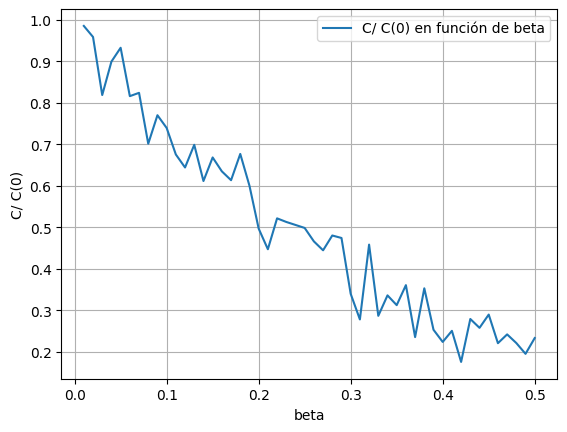

In [7]:
#Grafica del coef de clust en función de beta

plt.plot(beta3, clustering3, label="C/ C(0) en función de beta")
plt.xlabel("beta")
plt.ylabel("C/ C(0)")
plt.legend()
plt.grid(True)
plt.show()

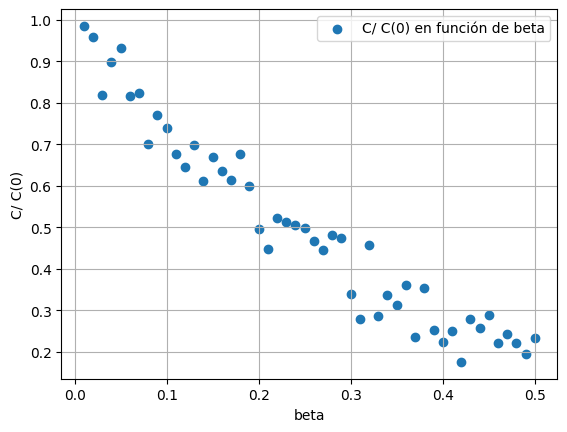

In [9]:
plt.scatter(beta3, clustering3, label="C/ C(0) en función de beta")
plt.xlabel("beta")
plt.ylabel("C/ C(0)")
plt.legend()
plt.grid(True)
plt.show()

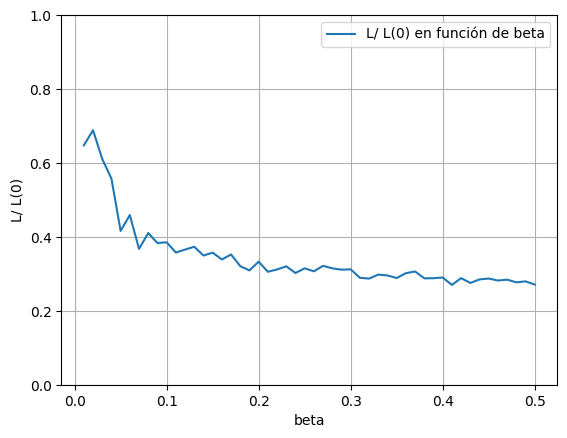

In [ ]:
#Grafica del num de aristas en función de beta

plt.plot(beta3, aristas3, label="L/ L(0) en función de beta")
plt.ylim(0, 1)
plt.xlabel("beta")
plt.ylabel("L/ L(0)")
plt.legend()
plt.grid(True)
plt.show()

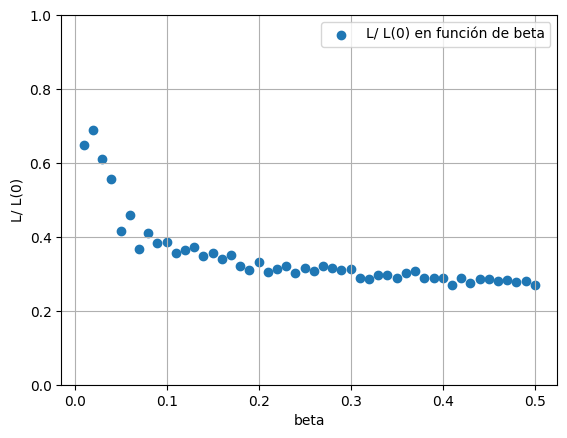

In [ ]:
#Grafica del num de aristas en función de beta

plt.scatter(beta3, aristas3, label="L/ L(0) en función de beta")
plt.ylim(0, 1)
plt.xlabel("beta")
plt.ylabel("L/ L(0)")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿Por qué se dice que una red está en el régimen de mundo pequeño cuando la longitud media de camino disminuye mucho, pero el clustering permanece relativamente alto?

**R=** Porque estaríamos diciendo que los vecinos están bastantes conectados, además que llegar de un nodo a otros (que no sean vecinos) es relativamente fácil.

## Ejercicio 4. Comparación entre Watts–Strogatz y Erdős–Rényi.

Considere una red de Watts–Strogatz con N=100, k=4 y un valor pequeño de $\beta$, y compárela con una red de Erdős–Rényi con número de nodos similar y grado promedio comparable.

- Genere ambas redes.
- Calcule en cada caso:
    - el coeficiente de clustering promedio,
    - la longitud media de camino.
- Dibuje ambas redes.
- Compare los resultados.

In [ ]:
N4 = 100
k4 = 4
beta = 0.027

W = nx.watts_strogatz_graph(N4, k4, beta)


grado_prom = 2 * W.number_of_edges() / N4


In [ ]:
p4 = grado_prom / (N4-1)

E = grafo_erdos_renyi(N4, p4, seed=None)

In [ ]:
#coef clust y long media de caminos para W

print(f"El coeficiente de clustering de W es {nx.average_clustering(W)}, mientras que su longitud media  es {nx.average_shortest_path_length(W)}")

El coeficiente de clustering de W es 0.469, mientras que su longitud media  es 9.053535353535354


In [ ]:
#coef clust y long media de caminos para E

print(f"El coeficiente de clustering de E es {nx.average_clustering(E)}")

El coeficiente de clustering de E es 0.025595238095238095


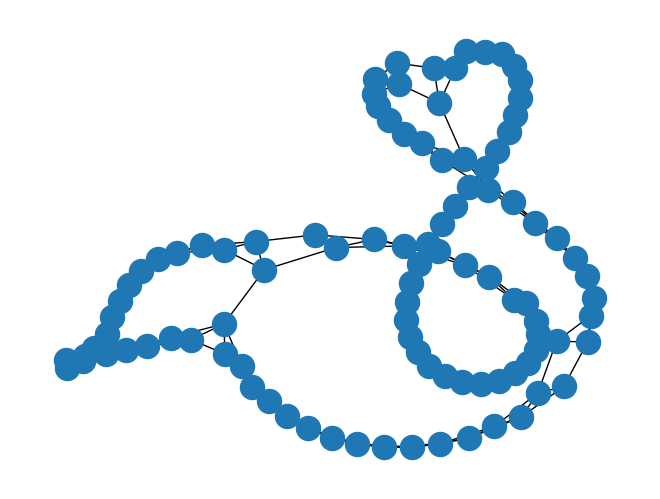

In [ ]:
nx.draw(W)

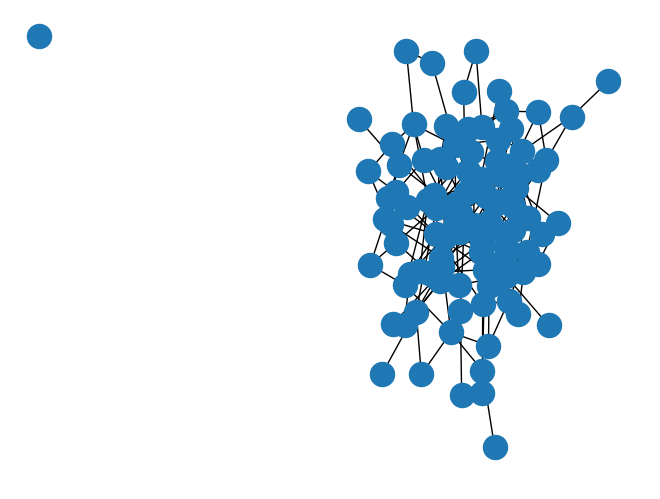

In [ ]:
nx.draw(E)

In [ ]:
e = E.subgraph(max(list(nx.connected_components(E))))

nx.average_shortest_path_length(e)

3.4153782725211297

In [ ]:
e.number_of_nodes() / E.number_of_nodes()

0.99

**Pregunta conceptual.**

¿Por qué una red de Watts–Strogatz puede presentar efecto de mundo pequeño de forma más clara que una red de Erdős–Rényi?

**R=** Porque mantiene el clustering alto (más conectados los nodos vecinos) y la longitud promedio baja